##1. Verifikasi Lingkungan Kerja
Dilakukan impor terhadap modul sys, platform, dan multiprocessing untuk mencetak versi interpreter Python, deskripsi sistem operasi, serta jumlah logical core CPU yang dialokasikan runtime Google Colab. Kemudian, dilakukan perulangan dengan __import__() untuk memeriksa ketersediaan pustaka utama (pandas, numpy, pyarrow, dan matplotlib) beserta versinya, dengan blok except ImportError yang menampilkan keterangan "Belum Terpasang" apabila pustaka belum terinsta

In [ ]:
import sys, platform, multiprocessing
print("Python :", sys.version.split()[0])
print("OS :", platform.platform())
print("CPU core: ", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
  try:
    mod = __import__(nama)
    print(f"{nama:11s}: {mod.__version__}")
  except ImportError:
    print(f"{nama:11s}: Belum Terpasang")

Python : 3.13.15
OS : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core:  2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


##1. Verifikasi Lingkungan Kerja
Dilakukan pemeriksaan sumber daya sistem melalui perintah shell yang dijalankan dari dalam Notebook dengan tanda seru (!), yaitu free -h untuk menampilkan kapasitas serta pemakaian memori RAM dan swap, df -h /content untuk menampilkan kapasitas dan sisa ruang penyimpanan pada direktori kerja /content, dan java -version untuk menampilkan versi Java Runtime Environment yang terpasang

In [ ]:
!free -h
!df -h /content
!java -version

               total        used        free      shared  buff/cache   available
Mem:            12Gi       977Mi       8.9Gi       2.1Mi       3.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.026s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.026s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


##2. Menghubungkan Google Drive dan menyiapkan struktur folder
Pada tahap ini, dilakukan penyambungan Google Drive ke runtime Colab melalui fungsi drive.mount() pada direktori /content/drive. Kemudian, diinisialisasikan dua variabel lokasi, yaitu DIR_KERJA sebagai direktori kerja sementara pada /content/data dan DIR_SIMPAN sebagai direktori penyimpanan permanen pada Google Drive. Kedua direktori tersebut dibuat menggunakan os.makedirs() dengan parameter exist_ok=True agar tidak menimbulkan error apabila direktori telah tersedia, lalu isi direktori penyimpanan ditampilkan dengan os.listdir() sebagai verifikasi bahwa proses penyambungan dan pembuatan direktori telah berhasil

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = '/content/data'
DIR_SIMPAN = '/content/drive/MyDrive/BigData/Praktikum1'
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
[]


##3. Menyiapkan alat ukur waktu dan memori
Dirancang sebuah alat pengukuran kinerja dengan memanfaatkan pustaka psutil untuk mengakses proses Notebook yang sedang berjalan melalui psutil.Process(os.getpid()), serta dideklarasikan list kosong catatan sebagai penampung hasil pengukuran. Function rss_mb() didefinisikan untuk mengembalikan besar memori Resident Set Size (RSS) yang digunakan proses dalam satuan megabyte(mb), sedangkan function ukur() digunakan untuk mengeksekusi suatu function tanpa argumen sekaligus mencatat durasi eksekusinya menggunakan time.perf_counter() dan pertumbuhan pemakaian memorinya. Hasil pengukuran tersebut di-append ke dalam list catatan dan ditampilkan ke layar.

In [ ]:
import time, os, psutil
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
  return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
  """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
  m0, t0 = rss_mb(), time.perf_counter()
  hasil = fungsi()
  detik = time.perf_counter() - t0
  delta = rss_mb() - m0
  catatan.append({"langkah": label, "detik": round(detik, 2),
                 "delta_rss_mb": round(delta, 1)})
  print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
  return hasil

##4. Mengunduh Dataset dan Inspeksi Awal
Dilakukan pengunduhan dataset NYC Yellow Taxi Trip Record periode Januari 2023 berformat Parquet dari server resmi NYC Taxi and Limousine Commission (TLC)menggunakan urllib.request.urlretrieve(), dengan lokasi berkas tujuan dibentuk melalui os.path.join() agar tersimpan pada direktori kerja yang telah ditetapkan sebelumnya. Pengunduhan dibungkus di dalam function ukur() supaya durasi dan pertumbuhan pemakaian memorinya tercatat, serta dikondisikan dengan pemeriksaan os.path.exists() sehingga proses hanya dijalankan apabila berkas belum tersedia dan tidak terjadi pengunduhan berulang saat cell dieksekusi kembali. Setelah proses selesai, ukuran berkas hasil unduhan ditampilkan dalam satuan MB melalui os.path.getsize() sebagai verifikasi bahwa dataset telah berhasil diperoleh secara utuh

In [ ]:
import urllib.request
URL = (
    "https://d37ci6vzurychx.cloudfront.net/trip-data/"
    "yellow_tripdata_2023-01.parquet"
)
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")
if not os.path.exists(PATH):
  ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file", round(os.path.getsize(PATH) / 1024**2, 1), "MB")


[unduh dataset] 0.32 s | RSS +1.7 MB
Ukuran file 45.5 MB


##4. Mengunduh Dataset dan Inspeksi Awal
Modul pyarrow.parquet diimpor dengan alias pq untuk membaca metadata berkas Parquet tanpa memuat keseluruhan isinya ke dalam memori. Berkas dibuka menggunakan pq.ParquetFile(), lalu atribut .metadata diakses guna memperoleh informasi jumlah baris, jumlah kolom, dan jumlah row group, sementara nama seluruh kolom ditampilkan melalui .schema.names.

In [ ]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row Group : ", meta.num_row_groups)
print("Nama Kolom : ", pq.ParquetFile(PATH).schema.names )

Jumlah baris : 3,066,766
Jumlah kolom : 19
Row Group :  1
Nama Kolom :  ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


##5. Memuat Data dan Mengukur Biaya Memori
Dilakukan impor pada library pandas, kemudian, diinisialisasikan list dengan nama KOLOM untuk menyimpan nama-nama kolom dataset yang telah ditentukan. Setelah itu, dilakukan pengukuran waktu eksekusi pembacaaan, dan jumlah RSS dataset  dengan membaca semua kolom, dan hanya kolom-kolom terpilih pada tabel. Setelah itu, ditampilkan dimensi dataset lengkap, jumlah memory yang digunakan dataset, beserta lima baris pertama dari dataset.  

In [ ]:
import pandas as pd

KOLOM = ['tpep_pickup_datetime', "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
df = ukur("Baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi: ", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()


[baca semua kolom] 1.50 s | RSS +495.3 MB
[Baca kolom terpilih] 0.61 s | RSS +229.5 MB
Dimensi:  (3066766, 19)
Memori : 565.6 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


##5. Memuat Data dan Mengukur Biaya Memori
Dilakukan penghapusan objek "penuh" pada scope sel dengan menggunakan keyword "del" kemudian, dilakukan impor pada library gc, dan dilakukan pembersihan memory dari object yang tidak lagi direferensi pada sel. Setelah itu, dilakukan pengukuran kecepatan pembacaan dan jumlah RSS dataframe dengan kolom yang telah ditentukan. Ditampilkan dimensi, dan penggunaan memori dalam satuan MB dataset.

In [ ]:
del penuh
import gc; gc.collect()

df = ukur("Baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi: ", df.shape)
print("Memori: ", round(df.memory_usage(deep=True).sum() / 1024 ** 2), "MB" )

[Baca kolom terpilih] 0.94 s | RSS +193.6 MB
Dimensi:  (3066766, 8)
Memori:  187 MB


##5. Memuat Data dan Mengukur Biaya Memori
Ditampilkan informasi mengenai penggunaan memori oleh dataframe yang diurutkan berdasarkan ukuran tertinggi.

In [ ]:
df.info(memory_usage='deep')
df.memory_usage(deep=True).sort_values(ascending=False) / 1024 ** 2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


##5. Memuat Data dan Mengukur Biaya Memori
Dilakukan pemeriksaan jumlah penggunaan memori setiap kolom dataset dengan menggunakan method .memory_usage dengan argumen deep=True, dan dijumlahkan menggunakan method .sum() untuk mengetahui jumlah penggunaan memory dari seluruh dataset, dan disimpan pada variabel "sebelum". Setelah itu, Dilakukan upaya penurunan penggunaan memori dengan mengubah datatype dari beberapa kolom menjadi datatype category dan float yang lebih sempit tanpa menghilangkan data. Dilakukan pemeriksaan penggunaaan memory, dan ditampilkan menggunakan method print().  

In [ ]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


##6. Pemeriksaan Kualitas Data dan Pembersihan (Veracity)
Kolom turunan durasi_menit dibentuk dari selisih antara waktu penurunan dan waktu penjemputan penumpang, yang kemudian dikonversi ke satuan menit melalui .dt.total_seconds() dibagi 60. Ringkasan statistik deskriptif atas kolom trip_distance, durasi_menit, dan total_amount ditampilkan dengan .describe(), diikuti pemeriksaan jumlah nilai kosong pada setiap kolom melalui .isna().sum(). Selanjutnya, empat jenis anomali data didefinisikan dalam sebuah dictionary, yakni jarak tempuh dan durasi bernilai nol atau negatif, durasi yang melebihi 180 menit, serta total tarif yang tidak wajar, dengan jumlah barisnya dihitung menggunakan boolean masking. Hasil perhitungan tersebut ditampilkan melalui perulangan beserta persentasenya terhadap total baris, sehingga tingkat kualitas dataset dapat dinilai sebelum tahap pembersihan data dilakukan

In [ ]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0": (df["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit" : (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum(),
}

for k, v in anomali.items():
  print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


##6. Pemeriksaan Kualitas Data dan Pembersihan (Veracity)
Kriteria kelayakan data disusun dalam sebuah boolean mask bernama layak yang menggabungkan empat kondisi menggunakan operator &, yaitu jarak tempuh lebih besar dari nol dan kurang dari 100 mil, durasi perjalanan berada pada rentang 1 hingga 180 menit melalui method .between(), serta total tarif bernilai positif. Mask tersebut diterapkan dengan df.loc[layak] dan disalin ke dataframe baru bernama bersih menggunakan .copy() agar terbentuk objek independen dan terhindar dari SettingWithCopyWarning pada tahap selanjutnya. Jumlah baris sebelum dan sesudah penyaringan kemudian dibandingkan beserta selisihnya, sehingga besarnya data anomali yang berhasil dibuang dapat diketahui secara kuantitatif

In [ ]:
layak = (
    (df['trip_distance'] >0 & (df["trip_distance"] < 100) & df["durasi_menit"].between(1, 180) &
     (df["total_amount"] > 0))
)

bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df) - len(bersih):,})")

3,066,766 baris -> 3,020,904 baris (dibuang 45,862)


##7. Memproses Data Lebih Besar dari Memori Menggunakan Chunking
Dataframe hasil pembersihan diekspor ke format CSV melalui .to_csv() dengan parameter index=False, dan proses penulisannya dibungkus dalam function ukur() agar durasi serta pemakaian memorinya tercatat. Ukuran berkas Parquet asli dan CSV hasil ekspor kemudian dibandingkan menggunakan os.path.getsize() untuk menunjukkan efisiensi penyimpanan format kolumnar dibandingkan format teks.

In [ ]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024 ** 2), "MB")
print("CSV :", round(os.path.getsize(CSV) / 1024 **2), "MB")

[tulis CSV] 40.05 s | RSS +5.2 MB
Parquet: 45 MB
CSV : 229 MB


##7. Memproses Data Lebih Besar dari Memori Menggunakan Chunking
Dilakukan pembuatan function agregasi_bertahap() untuk menerapkan teknik chunking untuk mengolah berkas CSV berukuran besar tanpa memuat seluruh isinya sekaligus ke dalam memori. Pembacaan dilakukan dengan pd.read_csv() yang dibatasi melalui parameter usecols agar hanya dua kolom yang relevan dimuat, parse_dates untuk mengonversi kolom waktu ke tipe datetime, serta chunksize yang memecah berkas menjadi potongan berisi 500.000 baris. Setiap chunk kemudian diiterasi untuk mengakumulasi jumlah baris dan total tarif, sementara agregasi per jam dilakukan dengan groupby() atas atribut .dt.hour dan hasilnya digabungkan secara inkremental ke dalam dictionary per_jam menggunakan .get() sebagai nilai awal. Proses tersebut dieksekusi melalui function ukur() agar kinerjanya dapat dibandingkan dengan pendekatan pemuatan penuh, lalu rata-rata total_amount dihitung dari hasil akumulasinya

In [ ]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
  jumlah_baris = 0
  total_nilai = 0.0
  per_jam = {}

  potongan = pd.read_csv(
      path,
      usecols=["tpep_pickup_datetime", "total_amount"],
      parse_dates =['tpep_pickup_datetime'],
      chunksize=ukuran_chunk
  )
  for chunk in potongan:
    jumlah_baris += len(chunk)
    total_nilai += chunk["total_amount"].sum()
    for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
      n, nilai = per_jam.get(jam, (0, 0.0))
      per_jam[jam] = (n+ len(sub), nilai + sub["total_amount"].sum())
  return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("Agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[Agregasi chunking] 4.81 s | RSS +31.6 MB
3,020,904 baris | rata-rata total_amount = 26.98


##8. Pendekatan Terdistribusi: Pyspark Local Mode
Dilakukan pengunduhan Pyspark versi 3.5.1 melalui pip, dan pemeriksaan versi java pada environment dengan menggunakan perintah -version.

In [ ]:
!pip install -q pyspark==3.5.1
!java -version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 9.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[0.002s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.002s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


##8. Pendekatan Terdistribusi: Pyspark Local Mode
SparkSession dibangun melalui pola builder sebagai titik masuk utama PySpark, dengan .appName() menetapkan nama aplikasi dan .master("local[*]") menjalankan Spark dalam mode lokal yang memanfaatkan seluruh core CPU yang tersedia. Dua konfigurasi tambahan diterapkan melalui .config(), yakni alokasi memori driver sebesar 4 GB dan jumlah partisi shuffle yang diturunkan menjadi 8 agar sesuai dengan skala eksekusi lokal. Method .getOrCreate() digunakan agar sesi yang telah ada dipakai ulang alih-alih membuat sesi baru, kemudian tingkat logging diturunkan ke WARN untuk menekan keluaran informatif Spark yang berlebihan, dan versi Spark ditampilkan sebagai verifikasi bahwa sesi berhasil dijalankan

In [ ]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark: ", spark.version)

Spark:  3.5.1


##8. Pendekatan Terdistribusi: Pyspark Local Mode
Berkas Parquet dibaca sebagai Spark DataFrame melalui spark.read.parquet(), lalu strukturnya ditampilkan dengan printSchema() dan jumlah barisnya dihitung menggunakan .count(). Pembersihan data disusun dalam rangkaian transformasi berantai, yakni pembentukan kolom durasi_menit melalui withColumn() dengan mengonversi kedua kolom waktu ke tipe long agar selisihnya diperoleh dalam satuan detik lalu dibagi 60, diikuti tiga filter() yang menerapkan kriteria kelayakan jarak, durasi, dan tarif sebagaimana pada pendekatan pandas sebelumnya. Agregasi dilakukan dengan menambahkan kolom jam melalui F.hour(), mengelompokkan data menggunakan groupBy(), dan menghitung jumlah perjalanan serta rata-rata jarak dan tarif melalui .agg() yang dibulatkan dengan F.round(). Seluruh transformasi tersebut bersifat lazy sehingga baru dieksekusi ketika .show() dipanggil di dalam function ukur().

##8. Error
Catatan error: cast langsung ke "long" gagal karena kolom datetime pada file Parquet ini bertipe TIMESTAMP_NTZ, dan Spark tidak mengizinkan konversi TIMESTAMP_NTZ -> BIGINT (DATATYPE_MISMATCH.CAST_WITHOUT_SUGGESTION). Solusi: gunakan timestampdiff() untuk menghitung selisih waktu dalam detik.

In [ ]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
              .withColumn(
                  "durasi_menit",
                  (F.col("tpep_dropoff_datetime").cast("long")
                  - F.col("tpep_pickup_datetime").cast("long")) / 60)
                  .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
                  .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
                  .filter(F.col("total_amount") > 0)
              )
hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 7.62 s | RSS +0.0 MB
Jumlah baris: 3066766


AnalysisException: [DATATYPE_MISMATCH.CAST_WITHOUT_SUGGESTION] Cannot resolve "CAST(tpep_dropoff_datetime AS BIGINT)" due to data type mismatch: cannot cast "TIMESTAMP_NTZ" to "BIGINT".;
'Project [VendorID#0L, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, store_and_fwd_flag#6, PULocationID#7L, DOLocationID#8L, payment_type#9L, fare_amount#10, extra#11, mta_tax#12, tip_amount#13, tolls_amount#14, improvement_surcharge#15, total_amount#16, congestion_surcharge#17, airport_fee#18, ((cast(tpep_dropoff_datetime#2 as bigint) - cast(tpep_pickup_datetime#1 as bigint)) / 60) AS durasi_menit#62]
+- Relation [VendorID#0L,tpep_pickup_datetime#1,tpep_dropoff_datetime#2,passenger_count#3,trip_distance#4,RatecodeID#5,store_and_fwd_flag#6,PULocationID#7L,DOLocationID#8L,payment_type#9L,fare_amount#10,extra#11,mta_tax#12,tip_amount#13,tolls_amount#14,improvement_surcharge#15,total_amount#16,congestion_surcharge#17,airport_fee#18] parquet


##8. Solusi Terhadap Error
Menghitung selisih waktu dengan fungsi timestampdiff(SECOND, awal, akhir) yang mendukung TIMESTAMP_NTZ, lalu dibagi 60 untuk memperoleh menit.

In [ ]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        F.expr("timestampdiff(SECOND, tpep_pickup_datetime, tpep_dropoff_datetime)") / 60)  # cast("long") error: TIMESTAMP_NTZ tidak bisa ke BIGINT
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))  # tarif harus positif

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))  # F.hour aman untuk TIMESTAMP_NTZ
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 0.89 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

##8. Pendekatan Terdistribusi: Pyspark Local Mode
DataFrame hasil pembersihan didaftarkan sebagai temporary view bernama trips melalui createOrReplaceTempView(), sehingga dapat dikueri menggunakan sintaks SQL standar lewat spark.sql(). Kueri ditulis untuk mengelompokkan data berdasarkan payment_type untuk menghitung jumlah perjalanan serta rata-rata tarif dan tip pada tiap metode pembayaran, lalu mengurutkannya dari terbesar. Setelah itu, rencana eksekusi kueri ditampilkan dengan explain() guna mengamati bagaimana Catalyst Optimizer menyusun proses di balik layar, dan sesi Spark ditutup melalui spark.stop() untuk membebaskan sumber daya

In [ ]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
        COUNT(*)          AS jumlah,
        ROUND(AVG(total_amount), 2) AS rata_tarif,
        ROUND(AVG(tip_amount), 2) AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
  """).show()

hasil_spark.explain()
spark.stop()

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2385064|      28.1|    4.16|
|           2| 512987|     23.58|     0.0|
|           0|  64106|     29.82|    4.06|
|           4|  15570|     24.11|    0.02|
|           3|   9184|     22.63|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#147 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#147 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=241]
      +- HashAggregate(keys=[jam#147], functions=[count(1), avg(trip_distance#67), avg(total_amount#79)])
         +- Exchange hashpartitioning(jam#147, 8), ENSURE_REQUIREMENTS, [plan_id=238]
            +- HashAggregate(keys=[jam#147], functions=[partial_count(1), partial_avg(trip_distance#67), partial_avg(total_amount#79)])
               +- Project [trip_distance#67, total_amount#79, hour(tpep_pickup_datetime#

##9. Agregasi Akhir dengan Pandas dan Penyimpanan Artefak
Kolom jam dibentuk dari atribut .dt.hour pada waktu penjemputan, kemudian data dikelompokkan dengan groupby() dan diringkas melalui .agg() menggunakan named aggregation untuk memperoleh jumlah perjalanan serta rata-rata jarak, durasi, tarif, dan median tarif pada tiap jam. Hasilnya dibulatkan dua angka desimal dengan .round(2) dan indeks kelompoknya dikembalikan menjadi kolom biasa melalui .reset_index(). Tabel agregasi tersebut kemudian diekspor ke Google Drive dalam format CSV dan Parquet, bersama list catatan yang dikonversi menjadi dataframe berisi rekapitulasi pengukuran kinerja.

In [ ]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
            .groupby("jam")
            .agg(jumlah_perjalanan=("total_amount", "size"),
                 rata_jarak=("trip_distance", "mean"),
                 rata_durasi=("durasi_menit", "mean"),
                 rata_tarif=("total_amount", "mean"),
                 median_tarif=("total_amount", "median"))
            .round(2)
            .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,83577,4.09,15.62,28.340000,21.360001
1,1,58695,3.55,14.87,25.959999,20.799999
2,2,41197,3.26,14.66,24.510000,20.520000
3,3,26732,3.84,14.65,25.610001,20.549999
4,4,17139,4.97,15.69,30.750000,22.200001
5,5,17340,15.90,15.57,35.939999,21.840000
6,6,42928,5.54,15.08,30.139999,18.480000
7,7,85397,5.34,15.13,26.629999,18.480000
8,8,115057,5.60,15.71,25.000000,18.959999
9,9,129185,3.16,15.30,25.270000,19.200001


##10. Visualisasi Hasil
Modul matplotlib.pyplot diimpor untuk memvisualisasikan hasil agregasi, dengan plt.subplots() membuat objek figure dan axes berukuran 9 × 3,4 inci. Diagram batang digambar melalui ax.bar() yang memetakan jam penjemputan pada sumbu X terhadap jumlah perjalanan pada sumbu Y, kemudian dilengkapi label sumbu dan judul, serta dirapikan tata letaknya dengan fig.tight_layout(). Grafik tersebut disimpan ke Google Drive dalam format PNG beresolusi 150 dpi melalui fig.savefig() sebelum ditampilkan dengan plt.show()

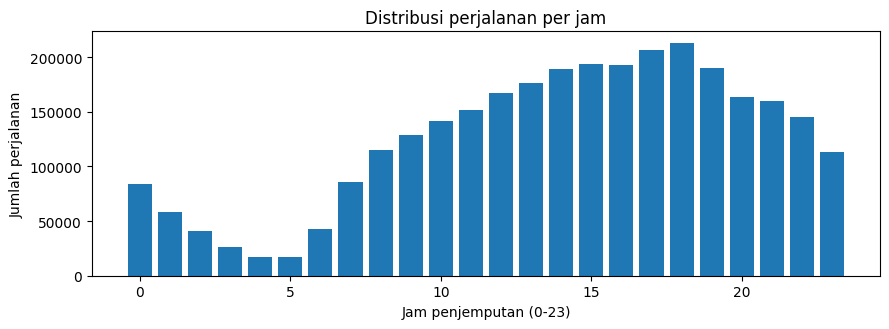

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

##O. Studi Kasus
Dimensi hari ditambahkan pada DataFrame bersih hasil pembersihan langkah 6 untuk menjawab tiga pertanyaan manajemen operator taksi, yaitu pada jam berapa permintaan tertinggi dan terendah, apakah polanya berbeda antara hari kerja dan akhir pekan, serta apakah perjalanan pada jam sibuk lebih pendek tetapi lebih menguntungkan per menit dibandingkan dengan jam lain. Kolom hari dibentuk dari nama hari melalui .dt.day_name(), kolom akhir_pekan bertipe *boolean* dari kondisi .dt.dayofweek >= 5 yang bernilai True untuk Sabtu dan Minggu, dan kolom tarif_per_menit dari pembagian total_amount dengan durasi_menit yang dibulatkan tiga angka desimal. Data kemudian dikelompokkan dengan groupby() atas pasangan akhir_pekan dan kolom jam dari langkah 9, lalu diringkas melalui .agg() menggunakan *named aggregation* untuk memperoleh jumlah perjalanan, rata-rata durasi, dan rata-rata tarif per menit pada setiap kelompok dengan pembulatan dua angka desimal oleh .round(2). Bagian awal tabel ringkas, yaitu 12 baris pertama, ditampilkan dengan .head(12) sebagai dasar penyusunan tabel jawaban, maksimal dua grafik, dan tiga rekomendasi operasional yang diminta studi kasus.

In [ ]:
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

ringkas = (bersih
           .groupby(["akhir_pekan", "jam"])
           .agg(jumlah=("total_amount", "size"), rata_durasi=("durasi_menit", "mean"),
                rata_tarif_per_menit=("tarif_per_menit", "mean"))
           .round(2))
ringkas.head(12)

jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       0     36048        15.93                  3.28
            1     17918        14.60                  3.86
            2      9731        14.40                  3.60
            3      6433        14.84                  3.88
            4      6422        16.76                   inf
            5     12721        15.03                  5.28
            6     36197        15.22                   inf
            7     74774        15.35                  2.71
            8     99186        16.32                   inf
            9    104199        16.17                   inf
            10   106220        16.20                   inf
            11   109844        16.12                   inf

##O. Studi Kasus
Baris bersih dibatasi ke rentang 1–31 Januari 2023 melalui between() dan disalin ke DataFrame kasus, lalu jumlah hari kalender hari kerja dan akhir pekan dihitung dari kolom tanggal dengan nunique() agar kedua kategori dibandingkan per hari, bukan per total baris, karena jumlah hari kerja dan hari akhir pekan dalam satu bulan tidak sama. Tabel per_jam merangkum jumlah perjalanan, rata-rata durasi, jarak, dan tarif per menit tiap jam melalui groupby("jam").agg(), sedangkan per_hari menghitung jumlah perjalanan tiap pasangan jam dan akhir_pekan dengan size().unstack() yang kemudian dibagi hari kalender masing-masing kategori. Keduanya digabung menjadi tabel_kasus dengan kolom penanda sibuk, yaitu jam dengan jumlah perjalanan di atas rata-rata seluruh jam, lalu tabel disimpan ke Drive sebagai studi_kasus_per_jam.csv dan ditampilkan sebagai tabel jawaban studi kasus.

In [ ]:
# batasi ke Januari 2023 agar jumlah hari kalender tiap kategori tepat
kasus = bersih.loc[bersih["tpep_pickup_datetime"].between("2023-01-01", "2023-01-31 23:59:59")].copy()
kasus["tanggal"] = kasus["tpep_pickup_datetime"].dt.date

hari_kalender = (kasus.groupby("akhir_pekan")["tanggal"].nunique()
                 .rename({False: "hari_kerja", True: "akhir_pekan"}))
print("Hari kalender:", hari_kalender.to_dict())

per_jam = (kasus
    .groupby("jam")
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_jarak=("trip_distance", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean")))

per_hari = (kasus
    .groupby(["jam", "akhir_pekan"]).size()
    .unstack("akhir_pekan")
    .rename(columns={False: "hari_kerja", True: "akhir_pekan"}))
per_jam["hari_kerja_per_hari"]  = per_hari["hari_kerja"]  / hari_kalender["hari_kerja"]
per_jam["akhir_pekan_per_hari"] = per_hari["akhir_pekan"] / hari_kalender["akhir_pekan"]

tabel_kasus = per_jam.round(2).reset_index()
tabel_kasus["sibuk"] = tabel_kasus["jumlah"] > tabel_kasus["jumlah"].mean()   # jam sibuk = permintaan di atas rata-rata
tabel_kasus.to_csv(f"{DIR_SIMPAN}/studi_kasus_per_jam.csv", index=False)
tabel_kasus

Hari kalender: {'hari_kerja': 22, 'akhir_pekan': 9}


,jam,jumlah,rata_durasi,rata_jarak,rata_tarif_per_menit,hari_kerja_per_hari,akhir_pekan_per_hari,sibuk
0,0,83565,15.62,4.09,inf,1638.00,5281.00,False
1,1,58695,14.87,3.55,inf,814.45,4530.78,False
2,2,41197,14.66,3.26,inf,442.32,3496.22,False
3,3,26731,14.65,3.84,3.06,292.36,2255.44,False
4,4,17139,15.69,4.97,inf,291.91,1190.78,False
5,5,17340,15.57,15.90,inf,578.23,513.22,False
6,6,42928,15.08,5.54,inf,1645.32,747.89,False
7,7,85396,15.13,5.34,2.96,3398.77,1180.33,False
8,8,115057,15.71,5.60,inf,4508.45,1763.44,False
9,9,129184,15.30,3.16,inf,4736.27,2776.22,True


##O. Studi Kasus
Pertanyaan pertama dijawab dengan mencetak jam bernilai jumlah tertinggi dan terendah melalui idxmax() dan idxmin(), dan pertanyaan kedua dengan jam puncak hari kerja serta akhir pekan dari kolom rata-rata per hari. Untuk pertanyaan ketiga, jam-jam sibuk dikumpulkan ke list jam_sibuk, setiap perjalanan pada kasus ditandai dengan isin(jam_sibuk), lalu tabel banding_sibuk membandingkan jumlah, rata-rata durasi, jarak, tarif, dan tarif per menit antara perjalanan pada jam sibuk dan jam lainnya. Perbandingan dihitung per perjalanan, bukan rata-rata dari rata-rata per jam, sehingga jam dengan lebih banyak perjalanan berbobot lebih besar.

In [ ]:
# (1) jam permintaan tertinggi dan terendah
tertinggi = tabel_kasus.loc[tabel_kasus["jumlah"].idxmax()]
terendah  = tabel_kasus.loc[tabel_kasus["jumlah"].idxmin()]
print(f"Permintaan tertinggi : pukul {tertinggi['jam']:.0f} ({tertinggi['jumlah']:,.0f} perjalanan)")
print(f"Permintaan terendah  : pukul {terendah['jam']:.0f} ({terendah['jumlah']:,.0f} perjalanan)")

# (2) jam puncak hari kerja vs akhir pekan, rata-rata per hari kalender
puncak_kerja = tabel_kasus.loc[tabel_kasus["hari_kerja_per_hari"].idxmax()]
puncak_pekan = tabel_kasus.loc[tabel_kasus["akhir_pekan_per_hari"].idxmax()]
print(f"Puncak hari kerja    : pukul {puncak_kerja['jam']:.0f} ({puncak_kerja['hari_kerja_per_hari']:,.0f} perjalanan/hari)")
print(f"Puncak akhir pekan   : pukul {puncak_pekan['jam']:.0f} ({puncak_pekan['akhir_pekan_per_hari']:,.0f} perjalanan/hari)")

# (3) jam sibuk vs jam lainnya, dihitung per perjalanan
jam_sibuk = tabel_kasus.loc[tabel_kasus["sibuk"], "jam"].tolist()
print("Jam sibuk            :", jam_sibuk)
kasus["sibuk"] = kasus["jam"].isin(jam_sibuk)

banding_sibuk = (kasus
    .groupby("sibuk")
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_jarak=("trip_distance", "mean"),
         rata_tarif=("total_amount", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .rename(index={True: "jam sibuk", False: "jam lainnya"}))
banding_sibuk

Permintaan tertinggi : pukul 18 (212,990 perjalanan)
Permintaan terendah  : pukul 4 (17,139 perjalanan)
Puncak hari kerja    : pukul 18 (7,318 perjalanan/hari)
Puncak akhir pekan   : pukul 16 (6,077 perjalanan/hari)
Jam sibuk            : [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


,jumlah,rata_durasi,rata_jarak,rata_tarif,rata_tarif_per_menit
sibuk,,,,,
jam lainnya,600852,15.30,4.94,27.469999,inf
jam sibuk,2420010,15.85,3.65,26.860001,inf


##O. Studi Kasus
Grafik ini menggambarkan rata-rata perjalanan per hari pada tiap jam untuk hari kerja dan akhir pekan sebagai dua garis dengan penanda berbeda melalui ax.plot(), sehingga pergeseran jam puncak antara kedua kategori terlihat langsung pada satu sumbu yang sama. Sumbu, judul, penanda 24 jam, dan legenda dilengkapi, lalu gambar disimpan ke Drive sebagai kasus_hari_kerja_vs_akhir_pekan.png beresolusi 150 dpi sebelum ditampilkan.

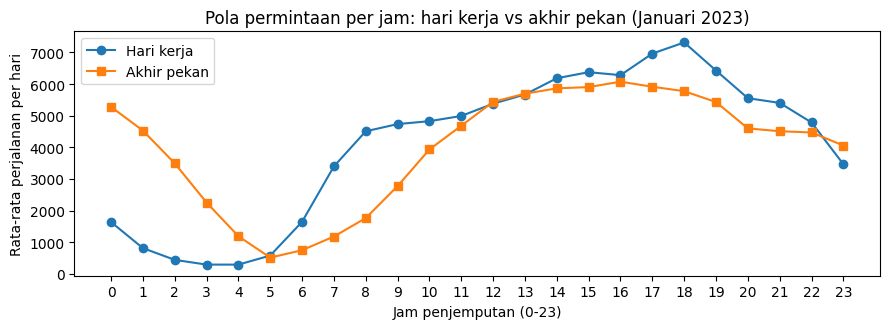

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(tabel_kasus["jam"], tabel_kasus["hari_kerja_per_hari"],  marker="o", label="Hari kerja")
ax.plot(tabel_kasus["jam"], tabel_kasus["akhir_pekan_per_hari"], marker="s", label="Akhir pekan")
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Rata-rata perjalanan per hari")
ax.set_title("Pola permintaan per jam: hari kerja vs akhir pekan (Januari 2023)")
ax.set_xticks(range(0, 24))
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/kasus_hari_kerja_vs_akhir_pekan.png", dpi=150)
plt.show()

##O. Studi Kasus
1. Jadwal *shift* dipadatkan pada pukul 16–19 dan dilonggarkan pada pukul 2–5, karena permintaan tertinggi terjadi pukul 18 (212.990 perjalanan dalam sebulan, sekitar 12 kali lipat pukul 4 yang hanya 17.139); batasannya, data ini hanya mencakup Januari 2023 yang merupakan musim dingin sehingga pola musiman belum tentu berlaku pada kuartal berikutnya.
2. Akhir pekan memerlukan jadwal tersendiri dengan porsi pengemudi dini hari yang lebih besar, karena pada pukul 0 rata-rata permintaan akhir pekan mencapai 5.281 perjalanan per hari, lebih dari tiga kali hari kerja (1.638), sementara puncak siangnya bergeser dari pukul 18 pada hari kerja ke pukul 16; batasannya, kategori akhir pekan hanya berisi 9 hari kalender termasuk hari libur 1 Januari sehingga rata-ratanya lebih mudah terpengaruh satu hari yang tidak biasa.
3. Penambahan armada pada jam sibuk (pukul 9–22) sebaiknya didasarkan pada volume permintaan, bukan pada asumsi keuntungan per menit, karena perjalanan pada jam sibuk justru sedikit lebih lama (rata-rata 15,85 menit dibandingkan 15,30 menit) dengan tarif rata-rata sedikit lebih rendah (26,86 USD dibandingkan 27,47 USD); batasannya, kolom tarif_per_menit tidak dapat dirata-ratakan (bernilai inf) karena data bersih masih memuat perjalanan berdurasi nol, sehingga perbandingan keuntungan per menit belum terverifikasi.

##P. Latihan

##Latihan 1
Lima baris dengan nilai trip_distance terbesar diambil dari DataFrame bersih menggunakan metode .nlargest() yang menerima jumlah baris dan nama kolom acuan sebagai argumen, lalu mengembalikan baris lengkap beserta seluruh kolomnya tanpa perlu mengurutkan keseluruhan tabel. Kewajaran setiap baris dapat dinilai dengan membandingkan jarak tempuhnya terhadap durasi_menit dan total_amount pada baris yang sama mengingat pada notebook ini penyaringan langkah 6 yang benar-benar berlaku hanya menahan jarak nol dan negatif, sehingga nilai jarak ekstrem masih dapat muncul pada tabel.

In [ ]:
#1. Latihan 1
print(bersih.nlargest(5, "trip_distance"))

        tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
3046991  2023-01-23 17:14:00   2023-01-23 17:20:00              NaN   
3009826  2023-01-07 18:18:00   2023-01-07 18:47:00              NaN   
3027106  2023-01-15 08:33:00   2023-01-15 08:43:00              NaN   
3021750  2023-01-13 05:53:00   2023-01-13 06:02:00              NaN   
3064729  2023-01-31 07:18:00   2023-01-31 07:57:00              NaN   

         trip_distance payment_type  fare_amount  tip_amount  total_amount  \
3046991      258928.15            0    13.650000        3.53     21.180000   
3009826      225987.37            0    56.490002       12.10     72.589996   
3027106      187872.33            0    14.020000        3.60     21.620001   
3021750      116439.71            0    13.220000        3.00     20.219999   
3064729       85543.66            0    39.900002        7.90     51.799999   

         durasi_menit  jam      hari  akhir_pekan  tarif_per_menit  
3046991           6.0   17    Monda

##Latihan 2
Fungsi agregasi_bertahap() dari langkah 7 dijalankan kembali dua kali melalui ukur() dengan argumen ukuran_chunk sebesar 100.000 lalu 1.000.000 baris, masing-masing dengan label berbeda agar kedua pengukuran tercatat terpisah di dalam list catatan dan dapat dibedakan dari entri "Agregasi chunking" pada langkah 7. Sebelum setiap percobaan, gc.collect() dipanggil untuk membebaskan objek yang tidak lagi direferensikan sehingga pertumbuhan RSS yang terukur hanya berasal dari proses *chunking* itu sendiri. Nilai kembalian berupa jumlah baris, total tarif, dan *dictionary* per jam ditampung pada variabel baris1, total1, nilai1 serta baris2, total2, nilai2, lalu jumlah baris dan rata-rata total_amount keduanya dicetak untuk memastikan ukuran potongan tidak mengubah hasil agregasi. Nilai detik dan delta_rss_mb yang dicetak ukur() pada kedua percobaan menjadi dasar untuk menjelaskan arah *trade-off* antara banyaknya iterasi pembacaan dan besarnya memori yang ditempati satu potongan.

In [ ]:
#2. Latihan 2
gc.collect() #membersihkan objek yang tidak digunakan dari memory, harus dilakukan setiap proses
baris1, total1, nilai1 = ukur("agregasi chunking 100k", lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000))

gc.collect()
baris2, total2, nilai2 = ukur("agregasi chunking 1M", lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000))

print(f"{baris1:,} baris | rata-rata total_amount = {total1/baris1:.2f}")
print(f"{baris2:,} baris | rata-rata total_amount = {total2/baris2:.2f}")

[agregasi chunking 100k] 5.17 s | RSS +22.4 MB
[agregasi chunking 1M] 4.22 s | RSS +84.0 MB
3,020,904 baris | rata-rata total_amount = 26.98
3,020,904 baris | rata-rata total_amount = 26.98


##Latihan 3
Rasio tip_amount terhadap fare_amount dihitung lalu dinyatakan dalam persen untuk membentuk kolom persen_tip, dan kasus fare_amount == 0 ditangani dengan .mask() yang mengganti nilai pada baris berkondisi fare_amount <= 0, termasuk tarif negatif, menjadi NaN. Dengan cara ini, nilai inf hasil pembagian dengan nol tidak terbawa ke kolom persen_tip dan baris tersebut diabaikan secara otomatis oleh .mean() serta .median(), alih-alih menyeret rata-rata mendekati nol seandainya nilai tersebut diisi nol. Data kemudian dikelompokkan dengan groupby() berdasarkan kolom kategori payment_type dengan observed=True agar hanya kategori yang benar-benar muncul pada data yang dihitung, lalu kolom persen_tip diringkas melalui .agg() menjadi jumlah baris valid, rata-rata, dan median dengan pembulatan dua angka desimal. Tabel hasil ditampilkan sebagai dasar untuk menduga penyebab perbedaan pola pemberian tip di antara metode pembayaran.

In [ ]:
#3. Latihan 3
rasio  = bersih["tip_amount"] / bersih["fare_amount"]
persen = rasio * 100
bersih["persen_tip"] = persen.mask(bersih["fare_amount"] <= 0).round(2)
hasil = (bersih
         .groupby("payment_type", observed=True)["persen_tip"]
         .agg(["count", "mean", "median"])
         .round(2))
hasil

,count,mean,median
payment_type,,,
0,64201,20.230000,22.490000
1,2390461,25.969999,26.129999
2,517040,0.000000,0.000000
3,10145,0.020000,0.000000
4,16535,0.140000,0.000000


##Latihan 4
DataFrame bersih ditulis dua kali ke direktori kerja dalam format Parquet melalui perulangan atas dua jenis kompresi, yaitu snappy dan gzip, menggunakan .to_parquet() dengan argumen compression= sesuai nama kompresi dan index=False agar indeks tidak ikut tersimpan. Setiap penulisan dibungkus dalam ukur() dengan label yang memuat nama kompresinya agar durasinya tercatat, lalu ukuran berkas yang dihasilkan dibaca dengan os.path.getsize() dan dikonversi ke MB, sedangkan waktu tulisnya diambil dari entri terakhir list catatan melalui catatan[-1]["detik"]. Kedua hasil dikumpulkan ke dalam list perbandingan dan ditampilkan sebagai DataFrame agar ukuran berkas dan waktu tulis kedua kompresi dapat dibandingkan secara langsung sebagai *trade-off* antara rasio kompresi dan biaya komputasi.

In [ ]:
#4. Latihan 4
perbandingan = []
for komp in ["snappy", "gzip"]:
    path = os.path.join(DIR_KERJA, f"bersih_{komp}.parquet")
    ukur(f"tulis parquet {komp}", lambda: bersih.to_parquet(path, compression=komp, index=False))
    perbandingan.append({
        "kompresi":  komp,
        "ukuran_mb": round(os.path.getsize(path) / 1024**2, 1),
        "detik":     catatan[-1]["detik"],
    })
pd.DataFrame(perbandingan)


[tulis parquet snappy] 3.02 s | RSS +11.5 MB
[tulis parquet gzip] 43.39 s | RSS +1.8 MB


,kompresi,ukuran_mb,detik
0,snappy,63.7,3.02
1,gzip,51.4,43.39


##Latihan 5
Karena sesi pada langkah 8 telah ditutup dengan spark.stop(), sesi Spark dibangun kembali melalui SparkSession.builder dengan konfigurasi yang sama, yaitu alokasi memori *driver* 4 GB dan delapan partisi *shuffle* melalui .config(), nama aplikasi melalui .appName(), serta mode lokal .master("local[*]") yang memakai seluruh inti CPU. Dua konfigurasi ditambahkan, yaitu spark.sql.parquet.inferTimestampNTZ.enabled bernilai false agar kolom waktu Parquet dibaca sebagai TIMESTAMP, bukan TIMESTAMP_NTZ yang tidak dapat di-cast ke long pada Spark 3.5, dan spark.sql.session.timeZone bernilai UTC agar F.hour() membaca jam apa adanya seperti .dt.hour pada pandas. Metode .getOrCreate() membuat sesi baru hanya apabila belum ada sesi yang aktif, kemudian tingkat log diturunkan ke WARN melalui setLogLevel() dan versi Spark dicetak sebagai verifikasi bahwa sesi siap dipakai untuk menulis ulang agregasi per jam langkah 9.

In [ ]:
#5. Latihan 5
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.sql.parquet.inferTimestampNTZ.enabled", "false")
         .config("spark.sql.session.timeZone", "UTC")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark: ", spark.version)

Spark:  3.5.1


##Latihan 5
Berkas Parquet dibaca kembali sebagai Spark DataFrame melalui spark.read.parquet(), skemanya ditampilkan dengan printSchema(), dan jumlah barisnya dihitung memakai .count() di dalam ukur() dengan label "spark count (L5)" agar tidak tertukar dengan catatan langkah 8. Kolom durasi_menit dibentuk melalui withColumn() dari selisih kedua kolom waktu yang dikonversi ke tipe long lalu dibagi 60, diikuti satu filter() dengan kriteria trip_distance > 0, yaitu kriteria yang meloloskan baris ke DataFrame bersih pada langkah 6 notebook ini, agar populasi baris yang diagregasi sepadan. Agregasi per jam langkah 9 ditulis ulang dengan API DataFrame dari modul pyspark.sql, yaitu kolom jam dari F.hour(), pengelompokan dengan groupBy(), dan .agg() yang menghasilkan lima kolom bernama sama dengan versi pandas, yakni jumlah_perjalanan dari F.count(), rata_jarak, rata_durasi, dan rata_tarif dari F.avg(), serta median_tarif dari F.median(), yang seluruhnya dibulatkan dua angka desimal dengan F.round() dan diurutkan berdasarkan jam. Karena transformasi Spark dievaluasi secara *lazy*, eksekusi baru terjadi ketika .toPandas() dipanggil di dalam ukur() dengan label "spark agregasi per jam (L5)". Metode .toPandas() dipilih alih-alih .show(), yang hanya mencetak tabel dan mengembalikan None, karena mengembalikan DataFrame pandas yang dapat disimpan ke variabel agregasi_spark, dibandingkan secara terprogram pada sel berikutnya, dan ditampilkan di akhir sel.

In [ ]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count (L5)", lambda: sdf.count()))

sdf_bersih = (sdf
              .withColumn(
                  "durasi_menit",
                  (F.col("tpep_dropoff_datetime").cast("long")
                  - F.col("tpep_pickup_datetime").cast("long")) / 60)
                  .filter(F.col("trip_distance") > 0)
              )
hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah_perjalanan"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("durasi_menit"), 2).alias("rata_durasi"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"),
         F.round(F.median("total_amount"), 2).alias("median_tarif"))
    .orderBy("jam"))

agregasi_spark = ukur("spark agregasi per jam (L5)", lambda: hasil_spark.toPandas())
agregasi_spark

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count (L5)] 0.26 s | RSS +0.0 MB
Jumlah baris: 3066766
[spark agregasi per jam (L5)] 8.25 s | RSS +0.0 MB


,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,83577,4.09,15.62,28.34,21.36
1,1,58695,3.55,14.87,25.96,20.80
2,2,41197,3.26,14.66,24.51,20.52
3,3,26732,3.84,14.65,25.61,20.55
4,4,17139,4.97,15.69,30.75,22.20
5,5,17340,15.90,15.57,35.94,21.84
6,6,42928,5.54,15.08,30.14,18.48
7,7,85397,5.34,15.13,26.63,18.48
8,8,115057,5.60,15.71,25.00,18.96
9,9,129185,3.16,15.30,25.27,19.20


##Latihan 5
Konsistensi kedua pendekatan dibuktikan secara terprogram dengan menggabungkan tabel agregasi hasil pandas dan agregasi_spark melalui .merge() pada kolom kunci jam, dengan argumen suffixes= yang memberi akhiran _pandas dan _spark pada kolom yang bernama sama. Kolom selisih dihitung sebagai nilai mutlak perbedaan jumlah_perjalanan kedua versi, lalu jumlah baris ketiga tabel beserta selisih maksimum kolom tersebut dicetak. Dua pernyataan assert menjadi bukti formalnya, yaitu ketiga tabel harus berjumlah baris sama agar tidak ada jam yang hilang di salah satu sisi, dan selisih maksimum kolom jumlah_perjalanan harus nol; apabila salah satunya gagal, eksekusi dihentikan oleh AssertionError beserta pesannya dan sumber selisih wajib ditelusuri, misalnya dari perbedaan kriteria penyaringan antara DataFrame bersih dan sdf_bersih. Untuk kolom rata_jarak, rata_durasi, rata_tarif, dan median_tarif hanya selisih maksimumnya yang dicetak karena pembulatan dan perbedaan presisi tipe data, yakni float32 pada pandas setelah optimasi tipe di langkah 5 terhadap double pada Spark, dapat menimbulkan perbedaan kecil yang wajar, lalu tabel perbandingan kolom jumlah dari kedua sisi beserta selisihnya ditampilkan di akhir sel.

In [ ]:
banding = agregasi.merge(agregasi_spark, on="jam", suffixes=("_pandas", "_spark"))
banding["selisih"] = (banding["jumlah_perjalanan_pandas"]
                      - banding["jumlah_perjalanan_spark"]).abs()

print("Baris pandas / Spark / gabungan:", len(agregasi), len(agregasi_spark), len(banding))
print("Selisih maksimum kolom jumlah  :", banding["selisih"].max())

assert len(agregasi) == len(agregasi_spark) == len(banding), "ada jam yang hilang di satu sisi"
assert banding["selisih"].max() == 0, "kolom jumlah TIDAK konsisten"
print("KONSISTEN: kolom jumlah identik di semua jam")

for kol in ["rata_jarak", "rata_durasi", "rata_tarif", "median_tarif"]:
    beda = (banding[f"{kol}_pandas"] - banding[f"{kol}_spark"]).abs().max()
    print(f"{kol:13s}: selisih maks {beda:.2f}")

banding[["jam", "jumlah_perjalanan_pandas", "jumlah_perjalanan_spark", "selisih"]]

Baris pandas / Spark / gabungan: 24 24 24
Selisih maksimum kolom jumlah  : 0
KONSISTEN: kolom jumlah identik di semua jam
rata_jarak   : selisih maks 0.00
rata_durasi  : selisih maks 0.00
rata_tarif   : selisih maks 0.00
median_tarif : selisih maks 0.00


,jam,jumlah_perjalanan_pandas,jumlah_perjalanan_spark,selisih
0,0,83577,83577,0
1,1,58695,58695,0
2,2,41197,41197,0
3,3,26732,26732,0
4,4,17139,17139,0
5,5,17340,17340,0
6,6,42928,42928,0
7,7,85397,85397,0
8,8,115057,115057,0
9,9,129185,129185,0


##Latihan 5
Rencana eksekusi fisik kueri agregasi ditampilkan melalui .explain() untuk mengamati operator ObjectHashAggregate  pada tahap agregasi parsial dan akhir serta Exchange yang menandai *shuffle* antarpartisi dalam rencana yang disusun Catalyst Optimizer,  modul. Setelah seluruh pembuktian selesai, sesi Spark ditutup dengan spark.stop() agar sumber daya yang dipegang sesi, termasuk memori *driver*, dibebaskan kembali.

In [ ]:
hasil_spark.explain()
spark.stop()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=true
+- == Final Plan ==
   *(2) Sort [jam#427 ASC NULLS FIRST], true, 0
   +- AQEShuffleRead coalesced
      +- ShuffleQueryStage 1
         +- Exchange rangepartitioning(jam#427 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=389]
            +- ObjectHashAggregate(keys=[jam#427], functions=[count(1), avg(trip_distance#347), avg(durasi_menit#405), avg(total_amount#359), percentile(total_amount#359, 0.5, 1, 0, 0, false)])
               +- AQEShuffleRead coalesced
                  +- ShuffleQueryStage 0
                     +- Exchange hashpartitioning(jam#427, 8), ENSURE_REQUIREMENTS, [plan_id=361]
                        +- ObjectHashAggregate(keys=[jam#427], functions=[partial_count(1), partial_avg(trip_distance#347), partial_avg(durasi_menit#405), partial_avg(total_amount#359), partial_percentile(total_amount#359, 0.5, 1, 0, 0, false)])
                           +- *(1) Project [trip_distance#347, total_amount#359, (cast((cast